# TUGAS MANDIRI Pertemuan 3
## Migrasi Data Transaksi E-Commerce ke HDFS

| | |
|---|---|
| **Nama** | Hilmi Mufid |
| **NIM** | 2505060046 |
| **Program Studi** | S1 Teknologi Informasi — Universitas Tidar |
| **Mata Kuliah** | Praktikum Big Data |
| **Pertemuan** | 3 |

---

### Konteks

Platform e-commerce tempat magang mulai bermigrasi ke infrastruktur Big Data. Data transaksi dari tiga cabang kota (Magelang, Yogyakarta, Semarang) yang sebelumnya berupa berkas CSV lepas di laptop analyst, sekarang disimpan secara terpusat di **HDFS** sebagai fondasi sebelum diproses lebih lanjut.

Notebook ini mendokumentasikan alur kerja lengkap: dari data mentah tiga kota → tersimpan rapi di HDFS → dibaca kembali dan diolah → hasil olahan disimpan kembali ke HDFS.

>**Environmental notes** : Seluruh praktikum ini dijalankan langsung di laptop Ubuntu (dual-boot), bukan di dalam mesin virtual (VM). Perintah Hadoop/HDFS tetap sama persis karena Hadoop berjalan sebagai proses OS biasa, tidak bergantung apakah OS-nya jalan di VM atau dual-boot.
>
>**Catatan path:** Mengikuti konvensi direktori kerja pribadi yang sudah digunakan pada modul praktikum (`/home/mufid/praktikum-bigdata0046`), maka `[username]` pada instruksi soal diganti menjadi `mufid`, sehingga struktur HDFS yang dipakai adalah `/home/mufid/praktikum-bigdata0046/ecommerce/...`.

---
## Persiapan membuat dataset 

Sebelum masuk ke bagian A-E, jalankan cell berikut untuk menghasilkan ***tigas berkas CSV*** 
yang mensimulasikan data transaksi dari tiga cabang kor=ta selama Agustus 2026.

In [3]:
# Sel ini menghasilkan TIGA dataset cabang (kota) terpisah untuk Tugas Mandiri Pertemuan 3
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)  # seed berbeda tiap kota agar datanya bervariasi, namun tetap konsisten/reproducible
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


### Proses pengerjaan 

## A. Membangun Struktur Direktori HDFS *(bobot 15%)*

Sebelum data diunggah, kita perlu menyiapkan struktur folder di HDFS terlebih dahulu,
mirip seperti membuat folder di file explorer sebelum meletakkan berkas ke dalamnya. Dibuat dua subfolder terpisah:
- `raw` → tempat menyimpan data mentah asli, belum diolah sama sekali.
- `processed` → tempat menyimpan hasil olahan/analisis.

Pemisahan ini penting agar data mentah tidak tercampur/rusak oleh proses pengolahan (dibahas lebih lanjut di bagian E).

In [4]:
# Membuar struktur direktori HDFS: raw dan processed
# '-p' memastikan parent folder (e-commerce) otomastis dibuat jika belum ada

!hdfs dfs -mkdir -p /home/mufid/praktikum-bigdata0046/ecommerce/raw
!hdfs dfs -mkdir -p /home/mufid/praktikum-bigdata0046/ecommerce/processed

# Verifikasi struktur folder sudah terbentuk
print("Isi folder ecommerce/:")
!hdfs dfs -ls /home/mufid/praktikum-bigdata0046/ecommerce

print("\nIsi folder ecommerce/raw (masih kosong):")
!hdfs dfs -ls /home/mufid/praktikum-bigdata0046/ecommerce/raw

print("\nIsi folder ecommerce/processed (masih kosong):")
!hdfs dfs -ls /home/mufid/praktikum-bigdata0046/ecommerce/processed

Isi folder ecommerce/:
Found 2 items
drwxr-xr-x   - mufid supergroup          0 2026-09-09 10:26 /home/mufid/praktikum-bigdata0046/ecommerce/processed
drwxr-xr-x   - mufid supergroup          0 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw

Isi folder ecommerce/raw (masih kosong):
Found 3 items
-rw-r--r--   1 mufid supergroup      12329 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 mufid supergroup      12154 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 mufid supergroup      12684 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_yogyakarta.csv

Isi folder ecommerce/processed (masih kosong):


## B. Mengunggah Data Mentah ke HDFS *(bobot 15%)*

**Penjelasan:** Ketiga berkas CSV (`transaksi_magelang.csv`, `transaksi_yogyakarta.csv`, `transaksi_semarang.csv`) 
yang masih berada di disk lokal VM, diunggah satu per satu ke folder `ecommerce/raw` di HDFS menggunakan perintah `put`.
Setelah itu, kita tampilkan isi direktori beserta ukurannya (`-ls -h`) sebagai bukti ketiga berkas berhasil terunggah.

In [5]:
# Upload ketiga berkas CSV ke HDFS folder raw
!hdfs dfs -put transaksi_magelang.csv /home/mufid/praktikum-bigdata0046/ecommerce/raw
!hdfs dfs -put transaksi_yogyakarta.csv /home/mufid/praktikum-bigdata0046/ecommerce/raw
!hdfs dfs -put transaksi_semarang.csv /home/mufid/praktikum-bigdata0046/ecommerce/raw

# Verifikasi: tampilkan isi direktori raw lengkap dengan ukuran berkas (-h = human-readable)
!hdfs dfs -ls -h /home/mufid/praktikum-bigdata0046/ecommerce/raw

put: `/home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 mufid supergroup     12.0 K 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 mufid supergroup     11.9 K 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 mufid supergroup     12.4 K 2026-09-09 10:42 /home/mufid/praktikum-bigdata0046/ecommerce/raw/transaksi_yogyakarta.csv


---
## C. Membaca Kembali dan Menggabungkan Data dari HDFS *(bobot 25%)*

Data yang sudah berada di HDFS dibaca kembali menggunakan Python (bukan dari disk lokal). Ada dua pendekatan umum untuk membaca berkas dari HDFS ke pandas:

1. Menggunakan perintah shell `hdfs dfs -cat` yang di-*pipe* ke `pandas.read_csv` melalui modul `io`.
2. Menggunakan library seperti `pyarrow`/`hdfs3` untuk koneksi langsung ke HDFS.

Pada praktikum ini dipakai pendekatan pertama karena paling sederhana dan tidak butuh instalasi tambahan — cukup memanfaatkan perintah HDFS CLI yang sudah terbukti berfungsi di bagian sebelumnya.

In [6]:
import subprocess
import io
import pandas as pd

def baca_csv_dari_hdfs(path_hdfs):
    """Membaca berkas CSV dari HDFS langsung ke pandas DataFrame,
    dengan memanfaatkan 'hdfs dfs -cat' lalu menangkap outputnya sebagai teks."""
    hasil = subprocess.run(
        ["hdfs", "dfs", "-cat", path_hdfs],
        capture_output=True, check=True
    )
    return pd.read_csv(io.BytesIO(hasil.stdout))

base_path = "/home/mufid/praktikum-bigdata0046/ecommerce/raw"

df_magelang = baca_csv_dari_hdfs(f"{base_path}/transaksi_magelang.csv")
df_yogyakarta = baca_csv_dari_hdfs(f"{base_path}/transaksi_yogyakarta.csv")
df_semarang = baca_csv_dari_hdfs(f"{base_path}/transaksi_semarang.csv")

print("Jumlah baris tiap kota (sebelum digabung):")
print(f"  Magelang   : {len(df_magelang)} baris")
print(f"  Yogyakarta : {len(df_yogyakarta)} baris")
print(f"  Semarang   : {len(df_semarang)} baris")

Jumlah baris tiap kota (sebelum digabung):
  Magelang   : 200 baris
  Yogyakarta : 200 baris
  Semarang   : 200 baris


In [7]:
# Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)

print(f"Total baris setelah digabung: {len(df_gabungan)}")
df_gabungan.head()

Total baris setelah digabung: 600


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


In [8]:
# Membuktikan hasil gabungan memang berisi transaksi dari ketiga kota
print("Jumlah transaksi per kota pada DataFrame gabungan:")
print(df_gabungan["kota"].value_counts())

Jumlah transaksi per kota pada DataFrame gabungan:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


---
## D. Mengolah dan Download Hasil ke Direktori `processed` *(bobot 25%)*

Pada tahap ini, DataFrame gabungan diolah lebih lanjut:
1. Menambahkan kolom `total_pendapatan` = `unit_terjual × harga_satuan`.
2. Membuat tabel ringkasan pendapatan per kombinasi **kota** dan **kategori** menggunakan `groupby`.
3. Kedua hasil (data gabungan bersih + tabel ringkasan) disimpan sebagai CSV baru di disk lokal, lalu diunggah ke folder `ecommerce/processed` di HDFS — terpisah dari data mentah di folder `raw`.


In [10]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

df_gabungan.head()

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000


In [11]:
# 2. Membuat tabel ringkasan: total pendapatan per kota DAN per kategori sekaligus
ringkasan_kota_kategori = (
    df_gabungan
    .groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
    .sort_values(["kota", "total_pendapatan"], ascending=[True, False])
)

ringkasan_kota_kategori

,kota,kategori,total_pendapatan
1,Magelang,Fashion,27750000
0,Magelang,Elektronik,18775000
3,Magelang,Makanan & Minuman,17525000
2,Magelang,Kesehatan & Kecantikan,17375000
4,Magelang,Rumah Tangga,12200000
6,Semarang,Fashion,26425000
5,Semarang,Elektronik,21425000
8,Semarang,Makanan & Minuman,19750000
7,Semarang,Kesehatan & Kecantikan,13525000
9,Semarang,Rumah Tangga,10975000


In [12]:
# 3. Menyimpan kedua hasil sebagai CSV baru di disk lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

print("Kedua berkas CSV hasil olahan berhasil disimpan di disk lokal:")
!ls -la data_gabungan_bersih.csv ringkasan_kota_kategori.csv

Kedua berkas CSV hasil olahan berhasil disimpan di disk lokal:
-rw-rw-r-- 1 mufid mufid 41257 Sep  9 19:41 data_gabungan_bersih.csv
-rw-rw-r-- 1 mufid mufid   530 Sep  9 19:41 ringkasan_kota_kategori.csv


In [13]:
# Mengunggah kedua berkas hasil olahan ke folder processed di HDFS
!hdfs dfs -put data_gabungan_bersih.csv /home/mufid/praktikum-bigdata0046/ecommerce/processed
!hdfs dfs -put ringkasan_kota_kategori.csv /home/mufid/praktikum-bigdata0046/ecommerce/processed

# Verifikasi kedua berkas sudah ada di folder processed
!hdfs dfs -ls -h /home/mufid/praktikum-bigdata0046/ecommerce/processed

Found 2 items
-rw-r--r--   1 mufid supergroup     40.3 K 2026-09-09 19:42 /home/mufid/praktikum-bigdata0046/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 mufid supergroup        530 2026-09-09 19:42 /home/mufid/praktikum-bigdata0046/ecommerce/processed/ringkasan_kota_kategori.csv


---
## E. Dokumentasi dan Refleksi *(bobot 20%)*

### 1. Screenshot NameNode Web UI
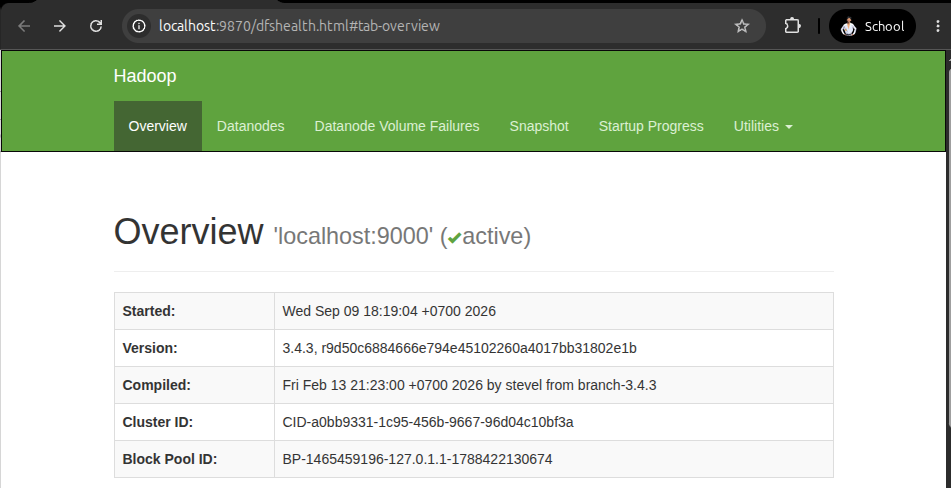

### 2. Utilities → Browse the file system
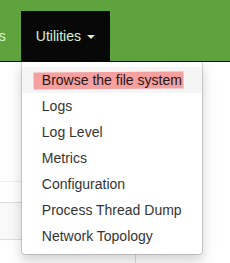

### 3. HDFS Root Directory
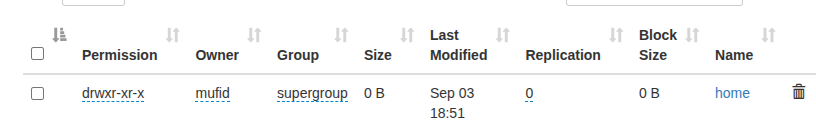

### 4. Home Directory User mufid
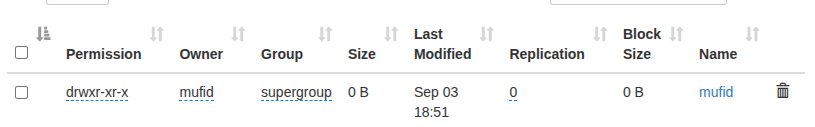

### 5. User Directory mufid
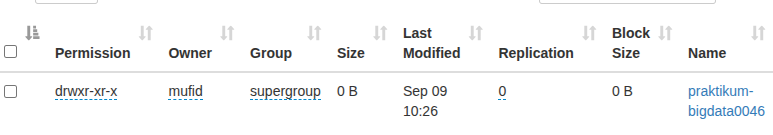

### 6. Folder Ecommerce dan Latihan3
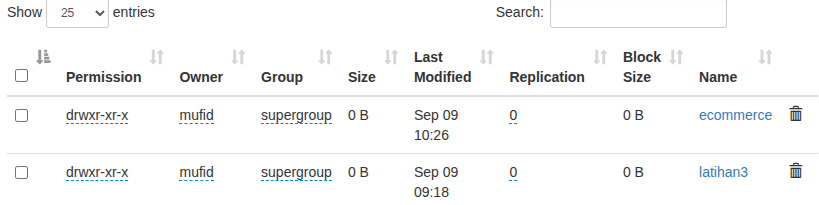

### 7. Folder Processed dan Raw
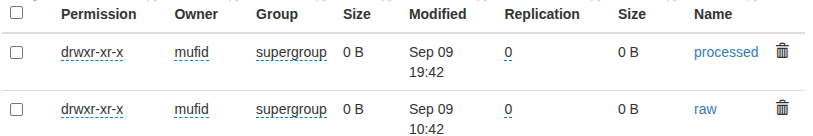

### 8. Isi Folder Processed
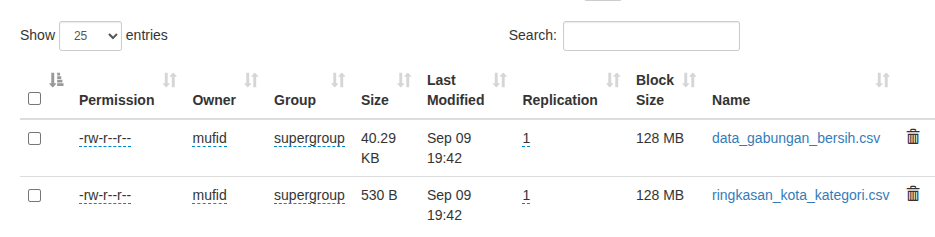

### 9. Isi Folder Raw
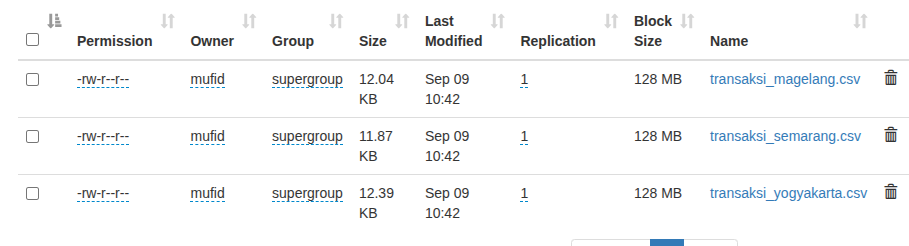


### 2. Refleksi (minimal 100 kata)

**Pertanyaan:** Apa keuntungan menyimpan data mentah (*raw*) terpisah dari data olahan (*processed*) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?

**Jawaban:**

Memisahkan data mentah (*raw*) dari data olahan (*processed*) di HDFS memberi beberapa keuntungan penting. Pertama, data mentah berfungsi sebagai *single source of truth* jika suatu saat ditemukan kesalahan pada logika pengolahan (misalnya rumus `total_pendapatan` yang keliru, atau kategori yang salah dikelompokkan), kita masih punya data asli yang belum tersentuh untuk diproses ulang dari awal, tanpa perlu meminta data ke sistem sumber lagi. Kedua, pemisahan ini membuat struktur folder lebih rapi dan mudah ditelusuri: siapa pun yang mengakses HDFS langsung tahu folder mana yang berisi data asli belum diolah dan mana yang sudah siap dianalisis, sehingga mengurangi risiko salah pakai (misalnya tidak sengaja menganalisis data yang sudah difilter sebagian). Ketiga, dari sisi tata kelola (*governance*) dan keamanan, folder `raw` biasanya perlu dijaga lebih ketat aksesnya karena berisi data asli yang mungkin sensitif, sedangkan folder `processed` bisa lebih terbuka untuk dikonsumsi tim analis atau dashboard. Terakhir, pemisahan ini juga mempermudah proses *audit* dan *reproducibility*: setiap hasil olahan bisa ditelusuri kembali ke data mentah asalnya, sehingga alur data (*data lineage*) dari mentah hingga siap pakai menjadi jelas dan dapat dipertanggungjawabkan.